# Google Speech Commands

In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

import warnings
warnings.filterwarnings('ignore')

import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))

import random

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset, ConcatDataset

from torchvision import models
import torchaudio

from sklearn.neighbors import KernelDensity

from tqdm import tqdm

import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

from joblib import Parallel, delayed

from utils import vectorize_tensor, reconstruct_tensor
import ld

device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")

## Setup

### General

In [2]:
def set_random_seed(seed):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    cp.random.seed(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

load = True

set_random_seed(42)
k = 3
bandwidth = 0.05
bandwidth_AE = 0.05
eps = np.asarray(1.0e-5)

### Dataset

In [3]:
class NumpyDataset(Dataset):
    def __init__(self, features, labels, transform=None):
        # Ensure features are in the correct shape [N, 1, 4000]
        if len(features.shape) == 1:
            features = features.reshape(1, 1, -1)
        elif len(features.shape) == 2:
            features = features.reshape(features.shape[0], 1, -1)

        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        sample = self.features[idx].float()
        label = self.labels[idx]

        if self.transform:
            sample = self.transform(sample)

        return sample, label

class Normalize:
    def __init__(self, mean, std):
        # Reshape mean and std to match input dimensions if necessary
        if not torch.is_tensor(mean):
            mean = torch.tensor(mean)
        if not torch.is_tensor(std):
            std = torch.tensor(std)

        # Add channel dimension if needed
        if len(mean.shape) == 1:
            mean = mean.reshape(1, -1)
        if len(std.shape) == 1:
            std = std.reshape(1, -1)

        self.mean = mean
        self.std = std

    def __call__(self, sample):
        # Ensure broadcasting works correctly
        return (sample - self.mean) / (self.std + eps)

# Your transform classes might need modification too
class AddGaussianNoise:
    def __init__(self, mean=0.0, std=0.1):
        self.mean = mean
        self.std = std

    def __call__(self, sample):
        # Ensure noise has the same shape as input
        noise = torch.randn_like(sample) * self.std + self.mean
        return sample + noise

# Composite transformation to combine Normalize and AddGaussianNoise
class CompositeTransform:
    def __init__(self, transforms):
        """
        Args:
            transforms (list): List of transformations to apply in sequence.
        """
        self.transforms = transforms

    def __call__(self, sample):
        for transform in self.transforms:
            sample = transform(sample)
        return sample

In [4]:
D = 4000
S = (2, 5, 2, 5, 2, 5, 2, 2)
train_size_per_class = 1000
new_sample_size_per_class = 200
num_class = 35

# Print dataset statistics
print(f"Train size: {train_size_per_class * num_class}")
print(f"New sample size: {new_sample_size_per_class * num_class}")
print(f"Number of classes: {num_class}")
print(f"Number of features: {D}")

Train size: 35000
New sample size: 7000
Number of classes: 35
Number of features: 4000


In [5]:
# Step 1: Load the dataset
train_dataset = torchaudio.datasets.SPEECHCOMMANDS(root='./data', download=True, subset='training')

def pad_or_truncate(waveform, target_length):
    """
    Pads or truncates the waveform to the target length.
    """
    waveform_length = waveform.shape[-1]
    if waveform_length > target_length:
        # Truncate
        return waveform[:, :target_length]
    elif waveform_length < target_length:
        # Pad with zeros
        padding = target_length - waveform_length
        return torch.nn.functional.pad(waveform, (0, padding))
    return waveform


# Step 2: Create directories and save audio files by class
save_dir = './data/SPEECH_audio'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    # Get unique labels
    all_labels = sorted(list(set(item[2] for item in train_dataset)))
    label_to_idx = {label: idx for idx, label in enumerate(all_labels)}

    # Save audio files by class
    for idx, (waveform, sample_rate, label, *_) in enumerate(train_dataset):
        class_label = label_to_idx[label]
        class_dir = os.path.join(save_dir, str(class_label))

        if not os.path.exists(class_dir):
            os.makedirs(class_dir)

        # Normalize to 1x16000
        waveform = pad_or_truncate(waveform, target_length=16000)
        waveform_np = waveform.numpy()

        # Sub-sampling to 1x4000
        waveform_np = waveform_np[:, ::4]
        np.save(os.path.join(class_dir, f'{idx}.npy'), waveform_np)

In [6]:
# Step 3: Function to load audio files from a directory
def load_audio_from_folder(folder, max_files=20):
    audio_files = []
    for filename in sorted(os.listdir(folder))[:max_files]:
        if filename.endswith('.npy'):
            audio = np.load(os.path.join(folder, filename))
            if audio is not None:
                audio_files.append(audio)

    # print(len(audio_files))
    return audio_files

# Step 4: Load audio and preprocess them
P_class = []

for class_ in range(num_class):
    class_folder = os.path.join(save_dir, str(class_))
    audio_files = load_audio_from_folder(class_folder, max_files=train_size_per_class)

    P = []
    for audio in audio_files:
        # Reshape audio to match your requirements
        array_obj = audio.reshape(S)  # or any other shape you need
        P.append(array_obj)
    P_class.append(np.array(P))

# Normalize to [0, 1]
P_class = np.array(P_class)
P_class = (P_class-P_class.min()) / (P_class.max()-P_class.min())

## Pseudo-Non-Linear Data Augmentation

### Legendre Decomposition (Many-Body Approximation)

In [7]:
B_LD = ld.default_B(S, 2, cp.get_array_module(P[0]))
# B_LD = ld.default_B(S, 2)
print(f"Dimension of Base Sub-Manifold: {B_LD.shape[0]}")

# Store all intermediate results to disk
if load:
    # Load all intermediate results from disk
    results = np.load('results_LD.npz')
    scaleX_class = results['scaleX_class']
    Q_class = results['Q_class']
    theta_class = results['theta_class']
    X_recons_class = results['X_recons_class']
else:
    import tempfile
    temp_dir = tempfile.mkdtemp(dir='/data/pbb/tmp')

    def LD_helper(i, class_):
        _, _, scaleX, Q, theta = ld.LD(P_class[class_][i], B=B_LD, verbose=False, n_iter=1000, lr=1e-1)
        return (scaleX, Q, theta)


    results = Parallel(n_jobs=30, temp_folder=temp_dir)(delayed(LD_helper)(i, class_) for i in range(train_size_per_class) for class_ in range(num_class))

    scaleX_class = []
    Q_class = []
    theta_class = []
    X_recons_class = []

    for class_ in range(num_class):
        scaleX_list = []
        Q_list = []
        theta_list = []
        X_recons_list = []
        for i in range(train_size_per_class):
            result = results[i*num_class + class_]

            scaleX_list.append(result[0])
            Q_list.append(result[1])
            theta_list.append(result[2])
            X_recons = (result[1] * result[0]).astype(np.int32)
            X_recons_list.append(X_recons)

        scaleX_class.append(np.array(scaleX_list))
        Q_class.append(np.array(Q_list))
        theta_class.append(np.array(theta_list))
        X_recons_class.append(np.array(X_recons_list))

    np.savez('results_LD.npz', scaleX_class=scaleX_class, Q_class=Q_class, theta_class=theta_class, X_recons_class=X_recons_class)

Dimension of Base Sub-Manifold: 136


#### Fitting on Projected Points

In [8]:
sampled_theta_class = []

for class_ in range(num_class):
    reduced_theta = vectorize_tensor(np.array(theta_class[class_]), B_LD)

    # Fit a KDE to the theta values
    kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth).fit(reduced_theta)
    # Sample new data from the KDE
    sampled_reduced_theta = kde.sample(n_samples=new_sample_size_per_class)

    sampled_theta = reconstruct_tensor(sampled_reduced_theta, (new_sample_size_per_class, *S), B_LD)

    sampled_theta_class.append(sampled_theta)

#### Construct Local-Data Sub-Manifold

In [9]:
# Construct the constrained coordinates
# B_BP = ld.block_B([14, 14], [15, 15])
B_BP = ld.default_B(S, 3, cp.get_array_module(P[0]))
# B_BP = ld.default_B(S, 3)
print(f"Dimension of Local Data Sub-Manifold: {D - B_BP.shape[0]}")

# Compute every datapoint's eta_hat (served as the linear constraints)
eta_hat_class = []

for class_ in range(num_class):
    eta_hat_list = []
    for i in range(P_class[class_].shape[0]):
        xp = cp.get_array_module(P_class[class_][i])
        # xp = np
        P = (P_class[class_][i] + eps) / scaleX_class[class_][i]
        eta_hat = ld.get_eta(P, len(S), xp)
        eta_hat_list.append(eta_hat)

    eta_hat_class.append(cp.asarray(eta_hat_list))
    # eta_hat_class.append(np.asarray(eta_hat_list))

Dimension of Local Data Sub-Manifold: 3430


#### Backward Projection

In [10]:
if load:
    # Load all intermediate results from disk
    results_BP = np.load('results_BP.npz')
    sampled_P_BP_class = results_BP['sampled_P_BP_class']
    sampled_theta_BP_class = results_BP['sampled_theta_BP_class']
    sampled_X_BP_class = results_BP['sampled_X_BP_class']
else:
    # Use a custom temporary directory
    import tempfile
    temp_dir = tempfile.mkdtemp(dir='/data/pbb/tmp')


    def BP_helper(i, class_):
        N = ld.kNN(sampled_theta_class[class_][i], theta_class[class_], k=k)
        avg_scale = np.mean(scaleX_class[class_][N])
        avg_eta_hat = np.mean(eta_hat_class[class_][N], axis=0)
        _, _, P, theta = ld.BP(sampled_theta_class[class_][i], [(P_class[class_][j] + eps) / scaleX_class[class_][j] for j in N], avg_eta_hat, avg_scale, B=B_BP, verbose=False, n_iter=1000, lr=1e-1)
        X_recons_ = (P).astype(np.int32).reshape(-1)
        return (P, theta, X_recons_)

    results = Parallel(n_jobs=10, temp_folder=temp_dir)(delayed(BP_helper)(i, class_) for i in range(new_sample_size_per_class) for class_ in range(num_class))

    sampled_P_BP_class = []
    sampled_theta_BP_class = []
    sampled_X_BP_class = []

    for class_ in range(num_class):
        sampled_P_BP = []
        sampled_theta_BP = []
        sampled_X_BP = []
        for i in range(new_sample_size_per_class):
            result = results[i*num_class + class_]

            sampled_P_BP.append(result[0])
            sampled_theta_BP.append(result[1])
            sampled_X_BP.append(result[2])

        sampled_P_BP_class.append(np.array(sampled_P_BP))
        sampled_theta_BP_class.append(np.array(sampled_theta_BP))
        sampled_X_BP_class.append(np.array(sampled_X_BP))

    np.savez('results_BP.npz', sampled_P_BP_class=sampled_P_BP_class, sampled_theta_BP_class=sampled_theta_BP_class, sampled_X_BP_class=sampled_X_BP_class)

## Data Augmentation with Autoencoder

In [11]:
class SpeechCommandsDataset(Dataset):
    def __init__(self, subset='training', transform=None):
        """
        Args:
            subset (str): 'training' or 'testing'
            transform (callable, optional): Optional transform to be applied
        """
        super().__init__()
        self.dataset = torchaudio.datasets.SPEECHCOMMANDS(
            root='./data',
            download=True,
            subset=subset
        )
        self.transform = transform

        # Get unique labels and create label mapping
        all_labels = sorted(list(set(item[2] for item in self.dataset)))
        self.label_to_idx = {label: idx for idx, label in enumerate(all_labels)}

        # Precompute all waveforms with subsampling
        print(f"Precomputing features for {subset} set...")
        self.precomputed_waveforms = []
        self.labels = []

        for waveform, _, label, *_ in tqdm(self.dataset):
            # Pad/truncate to 16000 first
            if waveform.shape[-1] > 16000:
                waveform = waveform[:, :16000]
            elif waveform.shape[-1] < 16000:
                padding = 16000 - waveform.shape[-1]
                waveform = torch.nn.functional.pad(waveform, (0, padding))

            # Subsample by taking every 4th sample
            waveform = waveform[:, ::4]  # Now length is 4000

            self.precomputed_waveforms.append(waveform)
            self.labels.append(self.label_to_idx[label])

        # Convert to tensors
        self.precomputed_waveforms = torch.stack(self.precomputed_waveforms)
        self.labels = torch.tensor(self.labels, dtype=torch.long)

        print(f"Precomputed {len(self.precomputed_waveforms)} waveforms")
        print(f"Waveform shape: {self.precomputed_waveforms[0].shape}")  # Should be [1, 4000]

    def __len__(self):
        return len(self.precomputed_waveforms)

    def __getitem__(self, idx):
        waveform = self.precomputed_waveforms[idx]
        label = self.labels[idx]

        if self.transform:
            waveform = self.transform(waveform)

        return waveform, label

In [12]:
class Encoder(nn.Module):
    def __init__(self, input_size=D, hidden_size=B_LD.shape[0], z_dim=3):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, z_dim)
        self.relu = nn.ReLU()
    def forward(self , x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class Decoder(nn.Module):
    def __init__(self, output_size=D, hidden_size=B_LD.shape[0], z_dim=3):
        super().__init__()
        self.fc1 = nn.Linear(z_dim , hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()
    def forward(self , x):
        x = self.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

Precomputing features for training set...


100%|██████████| 84843/84843 [04:34<00:00, 309.28it/s]


Precomputed 84843 waveforms
Waveform shape: torch.Size([1, 4000])


100%|██████████| 100/100 [14:21<00:00,  8.61s/it]


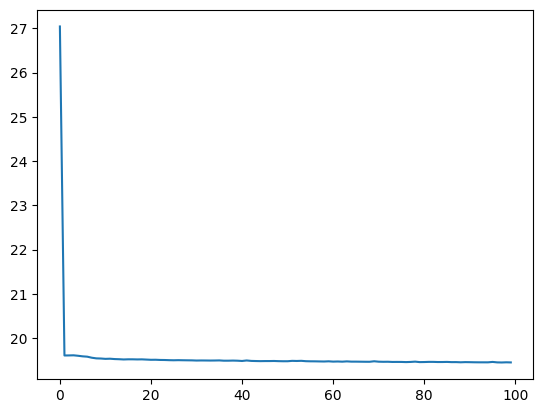

In [13]:
train_loader_original = DataLoader(SpeechCommandsDataset(subset='training'), batch_size=32, shuffle=True)

enc = Encoder().to(device)
dec = Decoder().to(device)
loss_fn = nn.MSELoss()
optimizer_enc = torch.optim.Adam(enc.parameters(), lr=1e-3)
optimizer_dec = torch.optim.Adam(dec.parameters(), lr=1e-3)

train_loss = []
num_epochs = 100

for epoch in tqdm(range(num_epochs)):
    train_epoch_loss = 0
    for (x , _) in train_loader_original:
        x = x.to(device)
        x = x.flatten(1)
        latents = enc(x)
        output = dec(latents)
        loss = loss_fn(output , x)
        train_epoch_loss += loss.cpu().detach().numpy()
        optimizer_enc.zero_grad()
        optimizer_dec.zero_grad()
        loss.backward()
        optimizer_enc.step()
        optimizer_dec.step()
    train_loss.append(train_epoch_loss)
plt.plot(train_loss)

In [14]:
representation = None
all_labels = []

with torch.no_grad():
    for (xs , labels) in train_loader_original:
        xs = xs.to(device)
        xs = xs.flatten(1)
        all_labels.extend(list(labels.numpy()))
        latents = enc(xs)
        if representation is None:
            representation = latents.cpu()
        else:
            representation = torch.vstack([representation , latents.cpu()])

all_labels = np.array(all_labels)
representation = representation.numpy()

In [15]:
sampled_X_AE_class = []

for class_ in range(num_class):
    sampled_X_AE_list = []

    rep = representation[np.argwhere(all_labels == class_)].squeeze()
    # Fit a KDE to the theta values
    kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth_AE).fit(rep)

    # Sample new data from the KDE
    sampled_rep = kde.sample(n_samples=new_sample_size_per_class)
    for i in range(new_sample_size_per_class):
        pred = dec(torch.Tensor(sampled_rep[i])[None , ...].to(device)).cpu().detach().numpy()
        sampled_X_AE_list.append(pred.flatten())

    sampled_X_AE_class.append(sampled_X_AE_list)

## Mixup

In [16]:
def mixup_data(x, y, alpha=1.0, device='cuda'):
    """
    Perform mixup on a batch of data.

    Args:
        x: Input features (batch_size, feature_dim)
        y: Labels (batch_size,)
        alpha: Beta distribution parameter for mixup
        device: Device to use

    Returns:
        mixed_x: Mixed inputs
        y_a: First set of labels
        y_b: Second set of labels
        lam: Mixing coefficient
    """
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0

    batch_size = x.size(0)

    # Generate random permutation of batch indices
    index = torch.randperm(batch_size).to(device)

    # Mix inputs: x_mixed = lam * x_i + (1 - lam) * x_j
    mixed_x = lam * x + (1 - lam) * x[index]

    # Return both labels for soft label computation
    y_a, y_b = y, y[index]

    return mixed_x, y_a, y_b, lam

def mixup_criterion(pred, y_a, y_b, lam, num_classes):
    """
    Compute mixup loss with soft labels.

    Soft label = lam * one_hot(y_a) + (1 - lam) * one_hot(y_b)
    Loss = CrossEntropy(pred, soft_label)

    Args:
        pred: Model predictions (logits) of shape (batch_size, num_classes)
        y_a: First set of labels (batch_size,)
        y_b: Second set of labels (batch_size,)
        lam: Mixing coefficient
        num_classes: Number of classes

    Returns:
        loss: Scalar loss value
    """
    criterion = nn.CrossEntropyLoss()
    # No one-hot conversion is needed
    loss = lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)
    return loss

def train_model_with_mixup(model, train_loader, criterion, optimizer, scheduler, num_epochs, alpha=1.0, num_classes=None, device='cuda'):
    """
    Train model with Mixup augmentation.

    Args:
        model: Neural network model
        train_loader: DataLoader for training data
        criterion: Loss function (not used for mixup, but kept for compatibility)
        optimizer: Optimizer
        scheduler: Learning rate scheduler
        num_epochs: Number of training epochs
        alpha: Mixup alpha parameter (0 means no mixup)
        num_classes: Number of classes (required for soft labels)
        device: Device to use
    """
    train_loss = []
    model.to(device)

    for epoch in tqdm(range(num_epochs)):
        model.train()
        train_epoch_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Apply mixup
            if alpha > 0:
                mixed_inputs, labels_a, labels_b, lam = mixup_data(inputs, labels, alpha, device)

                optimizer.zero_grad()
                outputs = model(mixed_inputs)

                # Compute mixup loss with soft labels
                loss = mixup_criterion(outputs, labels_a, labels_b, lam, num_classes)
            else:
                # No mixup
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()
            train_epoch_loss += loss.item()

        scheduler.step()
        train_loss.append(train_epoch_loss)

    plt.plot(train_loss)

print("Mixup functions defined successfully")

Mixup functions defined successfully


## Classification Performance

### Dataset Preparation

In [17]:
# Helper function to create a DataLoader for augmented datasets
def prepare_augmented_dataset(original_dataset, augmented_data, augmented_labels, transform, batch_size, augmented_ratio=1.0):
    # Ensure augmented data has the correct shape [N, 1, 4000]
    if len(augmented_data.shape) == 1:
        augmented_data = augmented_data.reshape(1, 1, -1)
    elif len(augmented_data.shape) == 2:
        augmented_data = augmented_data.reshape(augmented_data.shape[0], 1, -1)

    # Reduce the size of augmented data according to the augmented_ratio
    total_augmented = len(augmented_data)
    num_selected = int(total_augmented * augmented_ratio)

    if num_selected < total_augmented:  # Sample only if reducing
        indices = np.random.choice(total_augmented, num_selected, replace=False)
        augmented_data = augmented_data[indices]
        augmented_labels = augmented_labels[indices]

    # Create dataset from augmented data
    augmented_dataset = NumpyDataset(features=augmented_data, labels=augmented_labels, transform=transform)

    # Combine with the original dataset
    combined_dataset = ConcatDataset([original_dataset, augmented_dataset])

    # Create a DataLoader for the combined dataset
    return DataLoader(dataset=combined_dataset, batch_size=batch_size, shuffle=True)

import torchaudio.transforms as T

# Main function to prepare datasets and loaders
def create_datasets_and_loaders(batch_size=64, augmented_ratio=1.0):
    # Define transformations
    train_dataset = SpeechCommandsDataset(subset='training')
    test_dataset = SpeechCommandsDataset(subset='testing')

    # Calculate normalization statistics from training data
    mean = torch.mean(train_dataset.precomputed_waveforms)
    std = torch.std(train_dataset.precomputed_waveforms)

    transform_standard = CompositeTransform([
        Normalize(mean, std),
        T.Vol(0.5 + 0.5 * torch.rand(1).item()),       # Random volume scaling
        T.TimeStretch(),
        T.MelSpectrogram(sample_rate=16000, n_mels=64),
        T.FrequencyMasking(freq_mask_param=15),
        T.TimeMasking(time_mask_param=35),
    ])
    transform_none = Normalize(mean, std)

    train_standard = train_dataset
    train_standard.transform = transform_standard
    train_none = train_dataset
    train_none.transform = transform_none

    test_dataset.transform = transform_none

    augmented_data_PNL, labels_PNL = [], []
    augmented_data_AE, labels_AE = [], []

    for class_ in range(num_class):
        for data_PNL in sampled_X_BP_class[class_]:
            augmented_data_PNL.append(data_PNL)
            labels_PNL.append(class_)

        for data_AE in sampled_X_AE_class[class_]:
            augmented_data_AE.append(data_AE)
            labels_AE.append(class_)

    augmented_data_PNL = np.array(augmented_data_PNL)
    labels_PNL = np.array(labels_PNL)
    augmented_data_AE = np.array(augmented_data_AE)
    labels_AE = np.array(labels_AE)

    mean_LD = augmented_data_PNL.mean(axis=0)
    std_LD = augmented_data_PNL.std(axis=0)
    transform_none_LD = Normalize(mean_LD, std_LD)

    mean_AE = augmented_data_AE.mean(axis=0)
    std_AE = augmented_data_AE.std(axis=0)
    transform_none_AE = Normalize(mean_AE, std_AE)

    # Combine Speech Commands dataset with a subset of augmented data
    train_loader_PNL = prepare_augmented_dataset(train_none, augmented_data_PNL, labels_PNL, transform_none_LD, batch_size, augmented_ratio)
    train_loader_AE = prepare_augmented_dataset(train_none, augmented_data_AE, labels_AE, transform_none_AE, batch_size, augmented_ratio)

    # DataLoader for Speech Commands only
    train_loader_standard = DataLoader(train_standard, batch_size=batch_size, shuffle=True)
    train_loader_none = DataLoader(train_none, batch_size=batch_size, shuffle=True)

    return {
        "standard": train_loader_standard,
        "none": train_loader_none,
        "PNL_augmented": train_loader_PNL,
        "AE_augmented": train_loader_AE,
    }, test_dataset

# Create dictionaries of loaders for different datasets
train_loader_standard = {}
train_loader_none = {}
train_loader_PNL = {}
train_loader_AE = {}

# Example Usage: Testing different dataset sizes
for ratio in [1.0]:  # Testing different proportions of augmented data
    print(f"Testing with augmented_ratio = {ratio}")
    loaders, test_dataset = create_datasets_and_loaders(batch_size=64, augmented_ratio=ratio)

    for name, loader in loaders.items():
        print(f"{name} loader:")
        for data, labels in loader:
            print(f"data shape: {data.shape}, Labels shape: {labels.shape}")
            break

    train_loader_standard[ratio] = loaders["standard"]
    train_loader_none[ratio] = loaders["none"]
    train_loader_PNL[ratio] = loaders["PNL_augmented"]
    train_loader_AE[ratio] = loaders["AE_augmented"]

Testing with augmented_ratio = 1.0
Precomputing features for training set...


100%|██████████| 84843/84843 [04:35<00:00, 307.46it/s]


Precomputed 84843 waveforms
Waveform shape: torch.Size([1, 4000])
Precomputing features for testing set...


100%|██████████| 11005/11005 [00:35<00:00, 309.80it/s]


Precomputed 11005 waveforms
Waveform shape: torch.Size([1, 4000])
standard loader:
data shape: torch.Size([64, 1, 4000]), Labels shape: torch.Size([64])
none loader:
data shape: torch.Size([64, 1, 4000]), Labels shape: torch.Size([64])
PNL_augmented loader:
data shape: torch.Size([64, 1, 4000]), Labels shape: torch.Size([64])
AE_augmented loader:
data shape: torch.Size([64, 1, 4000]), Labels shape: torch.Size([64])


### ResNet18 Model

In [18]:
import torch.nn.functional as F

class M5(nn.Module):
    """
    M5 model architecture adapted for subsampled audio (4000 samples instead of 16000)
    """
    def __init__(self, n_input=1, n_output=35, stride=4, n_channel=32):
        super().__init__()

        # Adjusted kernel sizes and strides for 4000-sample input
        self.conv1 = nn.Conv1d(n_input, n_channel, kernel_size=20, stride=stride).float()
        self.bn1 = nn.BatchNorm1d(n_channel).float()
        self.pool1 = nn.MaxPool1d(4)

        self.conv2 = nn.Conv1d(n_channel, n_channel, kernel_size=3).float()
        self.bn2 = nn.BatchNorm1d(n_channel).float()
        self.pool2 = nn.MaxPool1d(4)

        self.conv3 = nn.Conv1d(n_channel, 2 * n_channel, kernel_size=3).float()
        self.bn3 = nn.BatchNorm1d(2 * n_channel).float()
        self.pool3 = nn.MaxPool1d(4)

        self.conv4 = nn.Conv1d(2 * n_channel, 2 * n_channel, kernel_size=3).float()
        self.bn4 = nn.BatchNorm1d(2 * n_channel).float()
        self.pool4 = nn.MaxPool1d(4)

        self.fc1 = nn.Linear(2 * n_channel, n_output).float()

    def forward(self, x):
        x = x.float()

        x = self.conv1(x)
        x = F.relu(self.bn1(x))
        x = self.pool1(x)

        x = self.conv2(x)
        x = F.relu(self.bn2(x))
        x = self.pool2(x)

        x = self.conv3(x)
        x = F.relu(self.bn3(x))
        x = self.pool3(x)

        x = self.conv4(x)
        x = F.relu(self.bn4(x))
        x = self.pool4(x)

        x = F.avg_pool1d(x, x.shape[-1])
        x = x.permute(0, 2, 1)
        x = self.fc1(x)

        return F.log_softmax(x, dim=2).squeeze()

def train_model(model, train_loader, criterion, optimizer, scheduler, num_epochs, device='cuda'):
    train_loss = []
    model.to(device)
    for epoch in tqdm(range(num_epochs)):
        model.train()
        train_epoch_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            try:
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                train_epoch_loss += loss.item()
            except Exception as e:
                print(f"Error: {e}")
                print(f"Inputs shape: {inputs.shape}, Labels shape: {labels.shape}, Outputs shape: {outputs.shape}")
                continue

        scheduler.step()
        train_loss.append(train_epoch_loss)

    plt.plot(train_loss)

def test_model(model, test_loader, device='cuda'):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

def bootstrapping(train_loader, test_dataset, num_epochs=100, learning_rate=1e-1, n_bootstrap=20, device='cuda'):
    """
    Train the ResNet model on the training dataset, and evaluate it using bootstrapping on the test dataset.

    Args:
        train_loader: DataLoader for training data.
        test_dataset: Dataset object for the test data.
        num_epochs: Number of epochs for training.
        learning_rate: Learning rate for the optimizer.
        device: Device to run the training on ('cuda' or 'cpu').

    Returns:
        Prints the mean accuracy and 95% confidence interval after bootstrapping.
    """
    # Initialize the model, loss, optimizer, and scheduler
    model = M5().to(device)
    model = model.float()
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)  # Decay LR every 30 epochs

    # Train the model
    train_model(model, train_loader, criterion, optimizer, scheduler, num_epochs=num_epochs, device=device)

    # Perform bootstrapping
    accuracies = []

    num_test_samples = len(test_dataset) // 2
    for i in range(n_bootstrap):
        indices = torch.randint(len(test_dataset), size=(num_test_samples,))  # Sample 500 random indices
        bootstrap_subset = Subset(test_dataset, indices)
        bootstrap_loader = DataLoader(dataset=bootstrap_subset, batch_size=num_test_samples, shuffle=False)

        accuracy = test_model(model, bootstrap_loader, device=device)
        accuracies.append(accuracy)

    # Compute statistics
    mean_accuracy = np.mean(accuracies)
    std_accuracy = np.std(accuracies)

    print(f"Mean accuracy: {mean_accuracy:.2f}%")
    print(f"Standard deviation: {std_accuracy:.2f}")

### Manifold Mixup

In [19]:
class M5_ManifoldMixup(nn.Module):
    """
    M5 model architecture adapted for subsampled audio (4000 samples) with Manifold Mixup support.
    """
    def __init__(self, n_input=1, n_output=35, stride=4, n_channel=32):
        super().__init__()

        # Adjusted kernel sizes and strides for 4000-sample input
        self.conv1 = nn.Conv1d(n_input, n_channel, kernel_size=20, stride=stride).float()
        self.bn1 = nn.BatchNorm1d(n_channel).float()
        self.pool1 = nn.MaxPool1d(4)

        self.conv2 = nn.Conv1d(n_channel, n_channel, kernel_size=3).float()
        self.bn2 = nn.BatchNorm1d(n_channel).float()
        self.pool2 = nn.MaxPool1d(4)

        self.conv3 = nn.Conv1d(n_channel, 2 * n_channel, kernel_size=3).float()
        self.bn3 = nn.BatchNorm1d(2 * n_channel).float()
        self.pool3 = nn.MaxPool1d(4)

        self.conv4 = nn.Conv1d(2 * n_channel, 2 * n_channel, kernel_size=3).float()
        self.bn4 = nn.BatchNorm1d(2 * n_channel).float()
        self.pool4 = nn.MaxPool1d(4)

        self.fc1 = nn.Linear(2 * n_channel, n_output).float()

    def forward(self, x, mixup_layer=None, mixup_index=None, mixup_lam=None):
        """
        Forward pass with optional manifold mixup.

        Args:
            x: Input audio
            mixup_layer: Layer at which to apply mixup (None, 0, 1, 2, or 3)
            mixup_index: Indices for mixing samples
            mixup_lam: Mixing coefficient
        """
        x = x.float()

        # Layer 0: First conv block
        if mixup_layer == 0 and mixup_index is not None and mixup_lam is not None:
            x = mixup_lam * x + (1 - mixup_lam) * x[mixup_index]

        x = self.conv1(x)
        x = torch.nn.functional.relu(self.bn1(x))
        x = self.pool1(x)

        # Layer 1: Second conv block
        if mixup_layer == 1 and mixup_index is not None and mixup_lam is not None:
            x = mixup_lam * x + (1 - mixup_lam) * x[mixup_index]

        x = self.conv2(x)
        x = torch.nn.functional.relu(self.bn2(x))
        x = self.pool2(x)

        # Layer 2: Third conv block
        if mixup_layer == 2 and mixup_index is not None and mixup_lam is not None:
            x = mixup_lam * x + (1 - mixup_lam) * x[mixup_index]

        x = self.conv3(x)
        x = torch.nn.functional.relu(self.bn3(x))
        x = self.pool3(x)

        # Layer 3: Fourth conv block
        if mixup_layer == 3 and mixup_index is not None and mixup_lam is not None:
            x = mixup_lam * x + (1 - mixup_lam) * x[mixup_index]

        x = self.conv4(x)
        x = torch.nn.functional.relu(self.bn4(x))
        x = self.pool4(x)

        x = torch.nn.functional.avg_pool1d(x, x.shape[-1])
        x = x.permute(0, 2, 1)
        x = self.fc1(x)

        return torch.nn.functional.log_softmax(x, dim=2).squeeze()

def train_model_with_manifold_mixup(model, train_loader, criterion, optimizer, scheduler, num_epochs, alpha=1.0, num_classes=None, device='cuda'):
    """
    Train M5 model with Manifold Mixup augmentation.

    Args:
        model: M5_ManifoldMixup model
        train_loader: DataLoader for training data
        criterion: Loss function (not used for mixup, but kept for compatibility)
        optimizer: Optimizer
        scheduler: Learning rate scheduler
        num_epochs: Number of training epochs
        alpha: Mixup alpha parameter (0 means no mixup)
        num_classes: Number of classes (required for soft labels)
        device: Device to use
    """
    train_loss = []
    model.to(device)

    # Number of possible mixup layers (0-3 for M5)
    num_layers = 4

    for epoch in tqdm(range(num_epochs)):
        model.train()
        train_epoch_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Apply manifold mixup
            if alpha > 0:
                # Randomly select which layer to apply mixup
                mixup_layer = np.random.randint(0, num_layers)

                # Sample mixing coefficient
                lam = np.random.beta(alpha, alpha)

                # Generate random permutation
                batch_size = inputs.size(0)
                index = torch.randperm(batch_size).to(device)

                optimizer.zero_grad()

                # Forward pass with manifold mixup
                outputs = model(inputs, mixup_layer=mixup_layer, mixup_index=index, mixup_lam=lam)

                # Compute mixup loss with soft labels
                loss = mixup_criterion(outputs, labels, labels[index], lam, num_classes)
            else:
                # No mixup
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()
            train_epoch_loss += loss.item()

        scheduler.step()
        train_loss.append(train_epoch_loss)

    plt.plot(train_loss)

def bootstrapping_mixup(train_loader, test_dataset, num_epochs=100, learning_rate=1e-1, alpha=1.0, n_bootstrap=20, device='cuda'):
    """
    Train M5 with Mixup and evaluate using bootstrapping.

    Args:
        train_loader: DataLoader for training data
        test_dataset: Dataset object for the test data
        num_epochs: Number of epochs for training
        learning_rate: Learning rate for the optimizer
        alpha: Mixup alpha parameter
        n_bootstrap: Number of bootstrap iterations
        device: Device to run the training on ('cuda' or 'cpu')

    Returns:
        Prints the mean accuracy and standard deviation after bootstrapping
    """
    # Initialize the model, loss, optimizer, and scheduler
    model = M5().to(device)
    model = model.float()
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

    # Train the model with Mixup
    train_model_with_mixup(model, train_loader, criterion, optimizer, scheduler,
                          num_epochs=num_epochs, alpha=alpha, num_classes=num_class, device=device)

    # Perform bootstrapping
    accuracies = []
    num_test_samples = len(test_dataset) // 2

    for i in range(n_bootstrap):
        indices = torch.randint(len(test_dataset), size=(num_test_samples,))
        bootstrap_subset = Subset(test_dataset, indices)
        bootstrap_loader = DataLoader(dataset=bootstrap_subset, batch_size=num_test_samples, shuffle=False)

        accuracy = test_model(model, bootstrap_loader, device=device)
        accuracies.append(accuracy)

    # Compute statistics
    mean_accuracy = np.mean(accuracies)
    std_accuracy = np.std(accuracies)

    print(f"Mean accuracy: {mean_accuracy:.2f}%")
    print(f"Standard deviation: {std_accuracy:.2f}")

def bootstrapping_manifold_mixup(train_loader, test_dataset, num_epochs=100, learning_rate=1e-1, alpha=1.0, n_bootstrap=20, device='cuda'):
    """
    Train M5 with Manifold Mixup and evaluate using bootstrapping.

    Args:
        train_loader: DataLoader for training data
        test_dataset: Dataset object for the test data
        num_epochs: Number of epochs for training
        learning_rate: Learning rate for the optimizer
        alpha: Manifold Mixup alpha parameter
        n_bootstrap: Number of bootstrap iterations
        device: Device to run the training on ('cuda' or 'cpu')

    Returns:
        Prints the mean accuracy and standard deviation after bootstrapping
    """
    # Initialize the model, loss, optimizer, and scheduler
    model = M5_ManifoldMixup().to(device)
    model = model.float()
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

    # Train the model with Manifold Mixup
    train_model_with_manifold_mixup(model, train_loader, criterion, optimizer, scheduler,
                                   num_epochs=num_epochs, alpha=alpha, num_classes=num_class, device=device)

    # Perform bootstrapping
    accuracies = []
    num_test_samples = len(test_dataset) // 2

    for i in range(n_bootstrap):
        indices = torch.randint(len(test_dataset), size=(num_test_samples,))
        bootstrap_subset = Subset(test_dataset, indices)
        bootstrap_loader = DataLoader(dataset=bootstrap_subset, batch_size=num_test_samples, shuffle=False)

        # Use model without mixup for evaluation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for features, labels in bootstrap_loader:
                features, labels = features.to(device), labels.to(device)
                outputs = model(features)  # No mixup during evaluation
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        accuracies.append(accuracy)

    # Compute statistics
    mean_accuracy = np.mean(accuracies)
    std_accuracy = np.std(accuracies)

    print(f"Mean accuracy: {mean_accuracy:.2f}%")
    print(f"Standard deviation: {std_accuracy:.2f}")

print("Evaluation functions for Mixup and Manifold Mixup defined successfully")

Evaluation functions for Mixup and Manifold Mixup defined successfully


### Dataset Performance

Testing with augmented_ratio = 1.0
Standard:


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [24:54<00:00, 29.90s/it]


Mean accuracy: 82.98%
Standard deviation: 0.50
None:


100%|██████████| 50/50 [24:49<00:00, 29.79s/it]


...

Mean accuracy: 83.13%
Standard deviation: 0.32
Mixup:


100%|██████████| 50/50 [25:19<00:00, 30.39s/it]


Mean accuracy: 81.85%
Standard deviation: 0.61
Manifold Mixup:


100%|██████████| 50/50 [25:50<00:00, 31.01s/it]


Mean accuracy: 83.06%
Standard deviation: 0.54


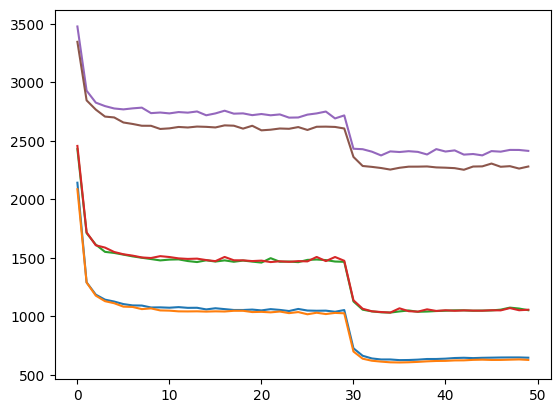

In [20]:
for ratio in [1.0]:
    print(f"Testing with augmented_ratio = {ratio}")
    print("Standard:")
    bootstrapping(train_loader_standard[ratio], test_dataset, num_epochs=50, learning_rate=0.1, device=device)
    print("None:")
    bootstrapping(train_loader_none[ratio], test_dataset, num_epochs=50, learning_rate=0.1, device=device)
    print("PNL:")
    bootstrapping(train_loader_PNL[ratio], test_dataset, num_epochs=50, learning_rate=0.1, device=device)
    print("AE:")
    bootstrapping(train_loader_AE[ratio], test_dataset, num_epochs=50, learning_rate=0.1, device=device)
    print("Mixup:")
    bootstrapping_mixup(train_loader_none[ratio], test_dataset, num_epochs=50, learning_rate=0.1, alpha=1.0, device=device)
    print("Manifold Mixup:")
    bootstrapping_manifold_mixup(train_loader_none[ratio], test_dataset, num_epochs=50, learning_rate=0.1, alpha=1.0, device=device)